# AnDi Dataset 


In [35]:
# Install relevant packages
import numpy as np
import matplotlib.pyplot as plt
from andi_datasets.models_phenom import models_phenom
from andi_datasets.datasets_theory import datasets_theory
from andi_datasets.utils_trajectories import plot_trajs
from andi_datasets.analysis import msd_analysis


In [27]:
# Load the dataset and list the available models
AD = datasets_theory()
print(AD.avail_models_name)


['attm', 'ctrw', 'fbm', 'lw', 'sbm']


In [50]:
# We want to study what happens if we increase the PEG concentration in the solution
# In the experimental setup, the PEG concentration was 15% and 18% in mass
# In particular, at higher concentrations of PEG, we expect more viscoelastic effects + confinement effects, which should lead to a more subdiffusive behavior of the particle

# Set the parameters of the dataset
L = 192 # length of a box in pixels 
N = 200 # number of trajectories 
T = 1000 # number of frames 
radius_compartments = 8 # radius of the compartments in pixels
number_compartments= 100 # number of compartments in the box -> it is computed as (Nc * pi * r^2) / (L^2)
trans = 0.4 # transition probability between compartments

compartments_center = models_phenom._distribute_circular_compartments(Nc = number_compartments, r = radius_compartments, L = L)






c:\Users\Attilio\Documents\Uni\Laboratorio_bio_I\Codici\.venv\Lib\site-packages\andi_datasets\models_phenom.py:1106: UserWarning: Could accomodate 91 circles of the 100 requested. Increase size of environment or decrease radius of compartments.
  warnings.warn(warn_str)


[0.0, 192.0, 0.0, 192.0, None]

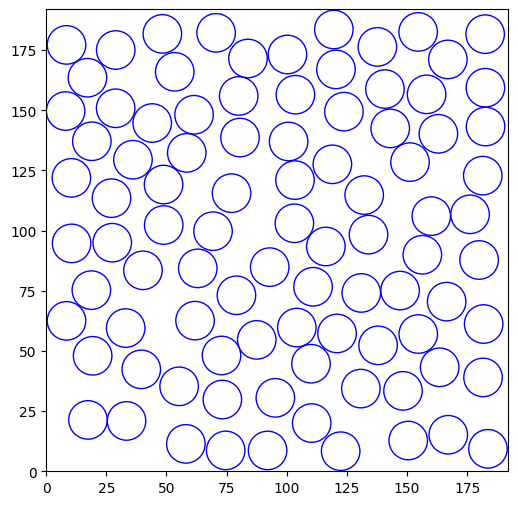

In [51]:
# Plot the compartments
fig, ax = plt.subplots(figsize=(6,6))
for c in compartments_center:
    circle = plt.Circle((c[0],c[1]), radius_compartments, color='blue', fill=False)
    ax.add_patch(circle)
plt.setp(ax, xlim=(0, L), ylim=(0, L), aspect=1)

In [53]:
# Simulate the trajectories
trajectories, labels = models_phenom().confinement(N = N, 
                                                   L = L,
                                                   Ds = [0.5, 0.25],
                                                   #alphas = [0.95, 0.95],
                                                   comp_center=compartments_center,
                                                   r = radius_compartments,
                                                   trans=trans
                                                   )

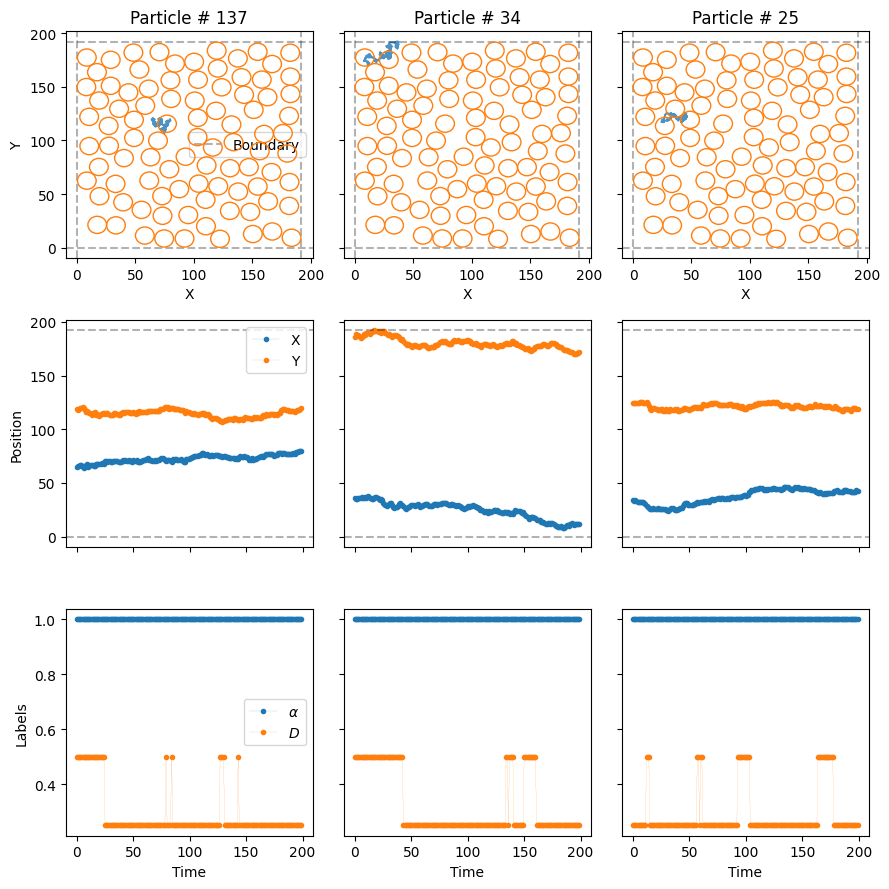

In [54]:
# Plots the trajectories
plot_trajs(trajs=trajectories, 
           L = L, 
           N = N, 
           comp_center=compartments_center,
           r_cercle= radius_compartments,
           plot_labels=True,
           labels=labels)

In [55]:
# Compute the taMSD (from andi dataset) and eaMSD (manually) for the simulated trajectories
# then plot the taMSD and eaMSD and extract the anomalous exponent alpha from the taMSD and eaMSD
# we can check ergodicity by comparing the taMSD and eaMSD and checking if they are similar or not

# Prepare the trajectories in shape expected by the andi_datasets: N x T x D
# N is the number of trajectories, T is the number of frames, D is the dimension (2 in our case)
trajectories_andi = trajectories.transpose(1,0,2) # from T x N x 2 to N x T x 2
N, T, D = trajectories_andi.shape
print(f"N: {N}, T: {T}, D: {D} ")



N: 200, T: 200, D: 2 


In [56]:
# Choose lag times for the taMSD and eaMSD
max_lag = T//2 # maximum lag time is half the length of the trajectory
t_lags = np.arange(1, max_lag + 1) # lag times from 1 to max_lag

# Compute the taMSD using the andi_datasets function
analysis = msd_analysis()
tamsd = analysis.tamsd(trajectories_andi, t_lags, dim=2)
tamsd_mean = tamsd.mean(axis=1) # average over trajectories

# Extract the anomalous exponent alpha from the taMSD by fitting a power law to the taMSD curve
alpha = np.polyfit(np.log(t_lags), np.log(tamsd_mean), 1)[0] # fit a line to log-log data, the slope is the anomalous exponent alpha

print(f"Anomalous exponent alpha from taMSD: {alpha:.2f}")

# Compute the eaMSD manually
# the eaMSD formula is MSD(tau) = 1/N * sum_{i=1}^N (x_i(t+tau) - x_i(t))^2 
eamsd = np.array([
    ((trajectories_andi[:, k, :] - trajectories_andi[:, 0, :]) ** 2).sum(axis=1).mean()
    for k in t_lags
])
# Extract the anomalous exponent alpha from the eaMSD by fitting a power law to the eaMSD curve
alpha_ea = np.polyfit(np.log(t_lags), np.log(eamsd), 1)[0] # fit a line to log-log data, the slope is the anomalous exponent alpha
print(f"Anomalous exponent alpha from eaMSD: {alpha_ea:.2f}")




Anomalous exponent alpha from taMSD: 0.96
Anomalous exponent alpha from eaMSD: 0.99


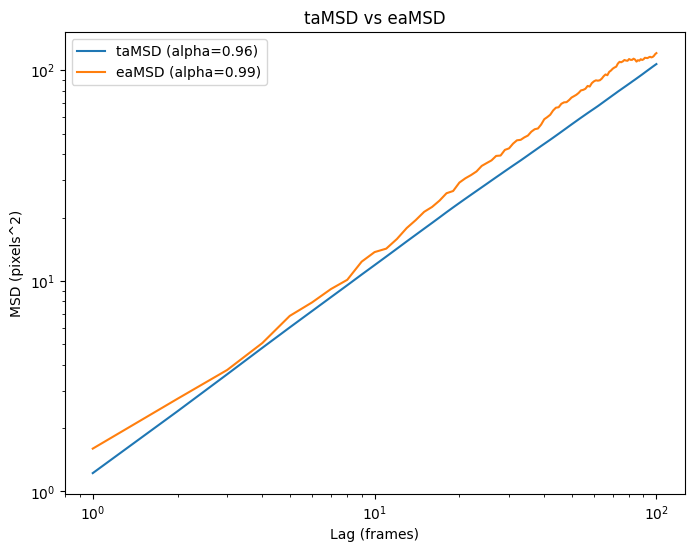

In [57]:
# Plot the taMSD and eaMSD curves
plt.figure(figsize=(8,6))
plt.loglog(t_lags, tamsd_mean, label=f'taMSD (alpha={alpha:.2f})')
plt.loglog(t_lags, eamsd, label=f'eaMSD (alpha={alpha_ea:.2f})')
plt.xlabel('Lag (frames)' )
plt.ylabel('MSD (pixels^2)')
plt.legend()
plt.title('taMSD vs eaMSD')
plt.show()